In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

In [34]:
df=pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
print(df.isnull().sum())
df = df[['Pclass', 'Sex', 'Embarked', 'Survived']]

df = df.dropna()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [36]:
print(df.isnull().sum())

Pclass      0
Sex         0
Embarked    0
Survived    0
dtype: int64


In [37]:
df['Sex']=df['Sex'].map({'male':0 , 'female':1})
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})
X=df[['Pclass', 'Sex', 'Embarked']]
y=df['Survived']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1172, stratify=y)

In [39]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=1172)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=1172)

In [40]:
y_pred = dt.predict(X_test)

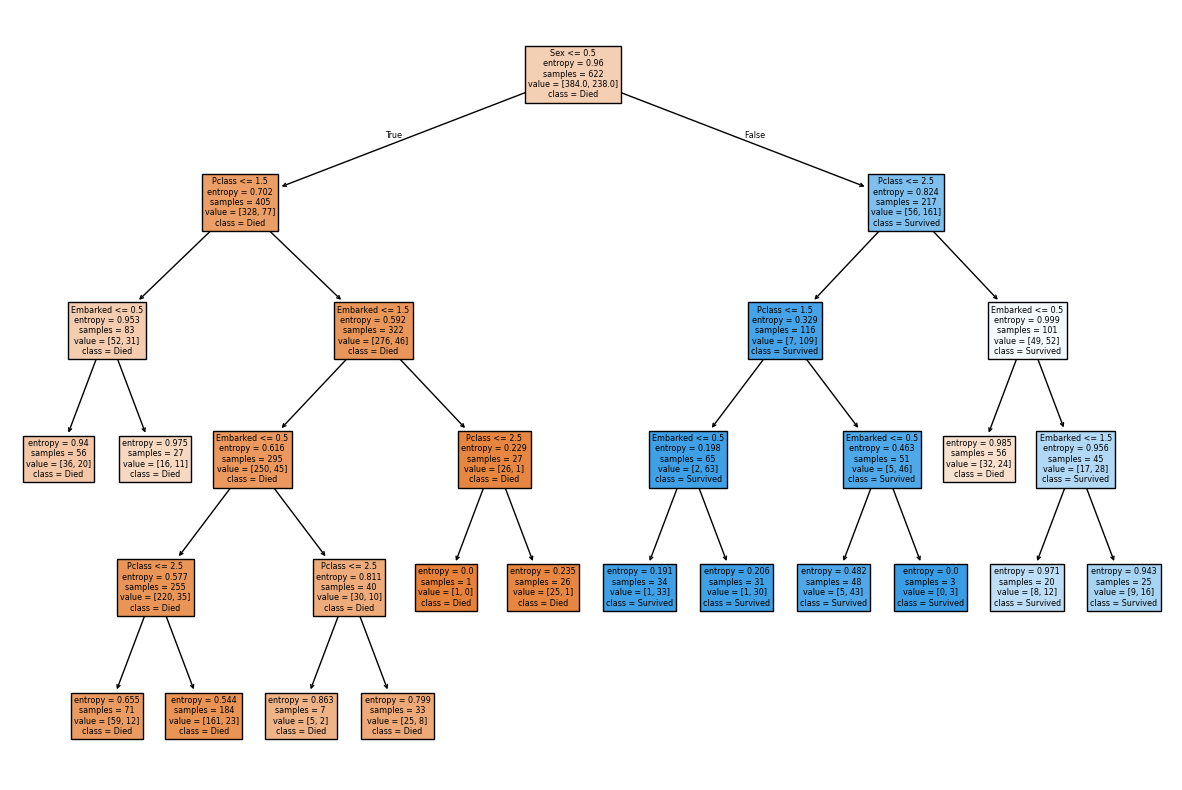

In [41]:
plt.figure(figsize=(15, 10))
plot_tree(dt, 
          feature_names=['Pclass', 'Sex', 'Embarked'], 
          class_names=['Died', 'Survived'], 
          filled=True)

plt.show()

In [42]:
probs = y_train.value_counts(normalize=True)

In [43]:
entropy_start = -np.sum(probs * np.log2(probs))

print(f"Start Entropy: {entropy_start:.4f}")

Start Entropy: 0.9599


In [44]:
def compute_entropy(y):
    probs = y.value_counts(normalize=True)
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

def compute_info_gain(df, attribute, target_name):
    total_entropy = compute_entropy(df[target_name])
    values = df[attribute].unique()
    weighted_entropy = 0
    
    for value in values:
        subset_y = df[df[attribute] == value][target_name]
        weight = len(subset_y) / len(df)
        weighted_entropy += weight * compute_entropy(subset_y)
    gain = total_entropy - weighted_entropy
    return gain

In [45]:
for feature in ['Pclass', 'Sex', 'Embarked']:
    gain = compute_info_gain(X_train.join(y_train), feature, 'Survived')
    print(f"Gain for {feature}: {gain:.4f}")

Gain for Pclass: 0.0830
Gain for Sex: 0.2156
Gain for Embarked: 0.0180
